In [7]:
#Retrieve the file path of the uploaded dataset 

import os
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files[:50]:
        print(os.path.join(root, f))


/kaggle/input/datasets/hanaksoy/reading-habits-and-mood-impact-dataset/sleep and psychological effects.csv


In [8]:
#import packages

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [9]:
# load datset and produce sample 5 rows

df = pd.read_csv("/kaggle/input/datasets/hanaksoy/reading-habits-and-mood-impact-dataset/sleep and psychological effects.csv")
df.head()


,User_ID,Age,Gender,Favorite_Book_Genre,Weekly_Reading_Time(hours),Mood_Impact
0,1,24,f,Fiction,6,Positive
1,2,32,m,Science,2,Neutral
2,3,18,f,Romance,8,Positive
3,4,45,m,History,3,Neutral
4,5,29,f,Fantasy,10,Positive


In [10]:
# Data quality Check - Completeness - check any missing values

missing = df.isna().sum()
missing


User_ID                       0
Age                           0
Gender                        0
Favorite_Book_Genre           0
Weekly_Reading_Time(hours)    0
Mood_Impact                   0
dtype: int64

In [11]:
# Data quality Check - Uniqueness - check any duplicate values
df["User_ID"].duplicated().sum()


np.int64(0)

In [12]:
# Data quality Check - Validity - Min and Max ranges 
df["Age"].min(), df["Age"].max(),
df["Weekly_Reading_Time(hours)"].min(), df["Weekly_Reading_Time(hours)"].max()


(1, 10)

In [13]:
# Data quality Check - Consistency- standardise text 
#(converts to string, removes leading spaces, )
df["Mood_Impact"] = df["Mood_Impact"].astype(str).str.strip().str.title()
df["Gender"] = df["Gender"].astype(str).str.strip().str.lower()
df["Favorite_Book_Genre"] = df["Favorite_Book_Genre"].str.strip().str.title()


In [14]:
# Data quality Check Plausibility - check are there any values below 0
df[df["Weekly_Reading_Time(hours)"] < 0]


,User_ID,Age,Gender,Favorite_Book_Genre,Weekly_Reading_Time(hours),Mood_Impact


In [15]:
# Data quality Check - Timeliness
df.columns


Index(['User_ID', 'Age', 'Gender', 'Favorite_Book_Genre',
       'Weekly_Reading_Time(hours)', 'Mood_Impact'],
      dtype='object')

In [16]:
#Counts how many values are in each category
df["Mood_Impact"].value_counts()


Mood_Impact
Positive    37
Neutral     16
Negative    12
Name: count, dtype: int64

In [17]:
#Counts how many values are in each category
df["Gender"].value_counts()


Gender
f    33
m    32
Name: count, dtype: int64

In [18]:
#Counts how many values are in each category

df["Favorite_Book_Genre"].value_counts()


Favorite_Book_Genre
Fiction      11
Fantasy      11
Science      10
Self-Help    10
Romance       9
Biography     8
History       6
Name: count, dtype: int64

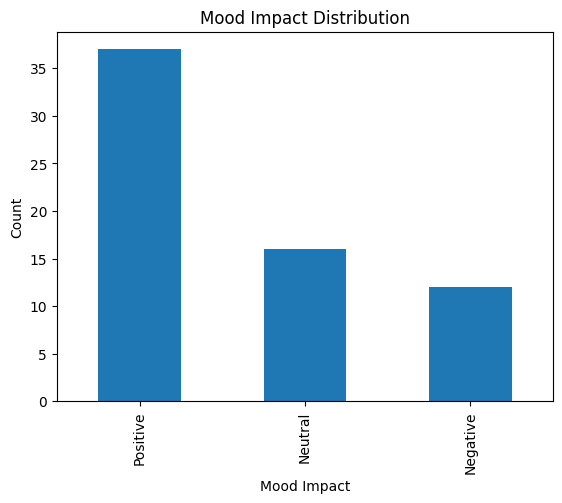

In [19]:
# to create a bar chart of mood impact
df["Mood_Impact"].value_counts().plot(kind="bar")
plt.title("Mood Impact Distribution")
plt.xlabel("Mood Impact")
plt.ylabel("Count")
plt.show()


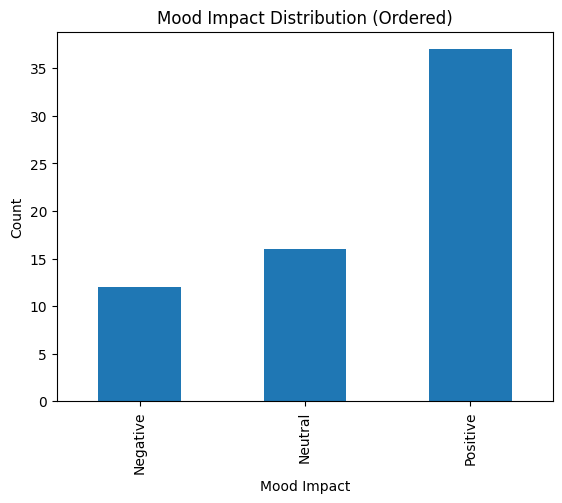

In [20]:
# to create a bar chart of mood impact - reordering values 
order = ["Negative", "Neutral", "Positive"]
mood_counts = df["Mood_Impact"].value_counts().reindex(order)

mood_counts.plot(kind="bar")
plt.title("Mood Impact Distribution (Ordered)")
plt.xlabel("Mood Impact")
plt.ylabel("Count")
plt.show()


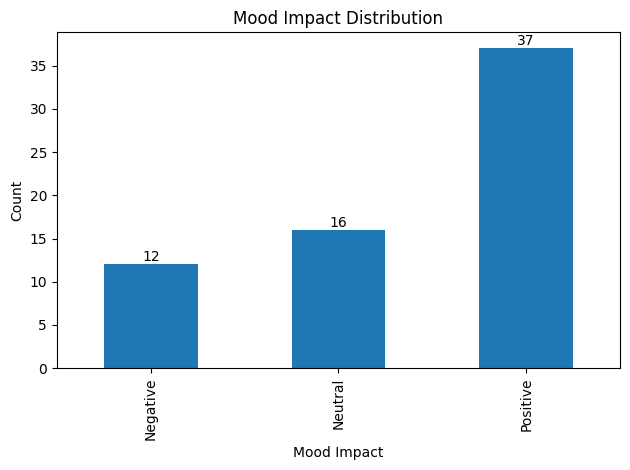

In [21]:
#to create a bar chart of Mood impacts with values on bars 

counts = df["Mood_Impact"].value_counts().reindex(["Negative","Neutral","Positive"])
ax = counts.plot(kind="bar")

ax.set_title("Mood Impact Distribution")
ax.set_xlabel("Mood Impact")
ax.set_ylabel("Count")

for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")

plt.tight_layout()
plt.show()



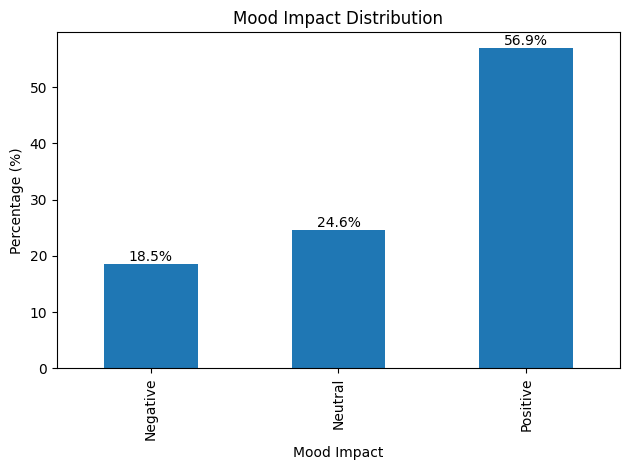

In [22]:
# to create a bar chart of Mood impacts with values as percentages shown on bars 
perc = (df["Mood_Impact"]
        .value_counts(normalize=True)
        .reindex(["Negative", "Neutral", "Positive"])
        .mul(100))
ax.set_ylim(0, 100)
ax = perc.plot(kind="bar")

ax.set_title("Mood Impact Distribution")
ax.set_xlabel("Mood Impact")
ax.set_ylabel("Percentage (%)")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")

plt.tight_layout()
plt.show()


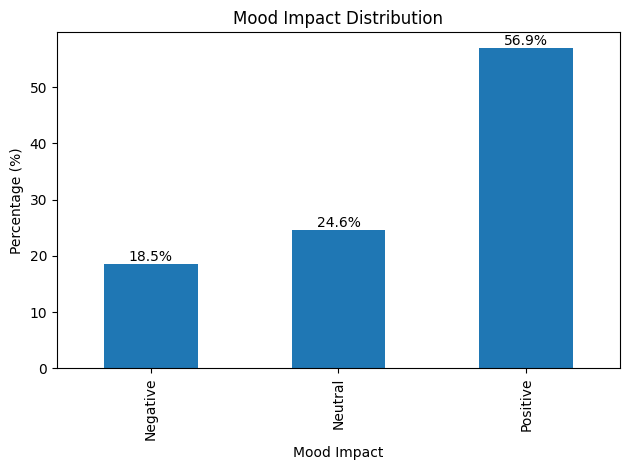

In [23]:
# Percentages for each mood category, ordered
perc = (df["Mood_Impact"]
        .value_counts(normalize=True)
        .reindex(["Negative", "Neutral", "Positive"])
        .mul(100))

# Plot
ax = perc.plot(kind="bar", color="#1f77b4")

# Titles / labels
ax.set_title("Mood Impact Distribution")
ax.set_xlabel("Mood Impact")
ax.set_ylabel("Percentage (%)")

# Add % labels above bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")

plt.tight_layout()
plt.show()

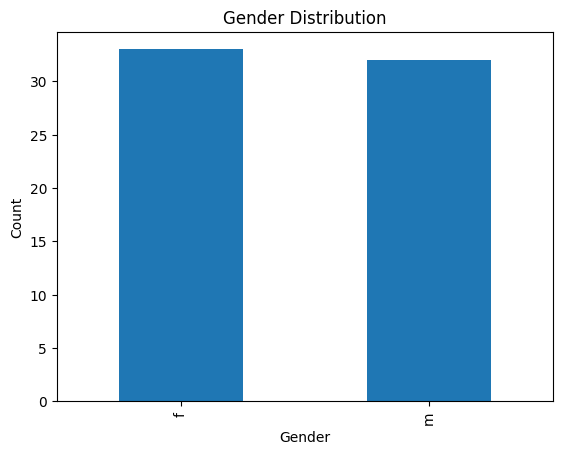

In [24]:
# to create a bar chart of gender
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


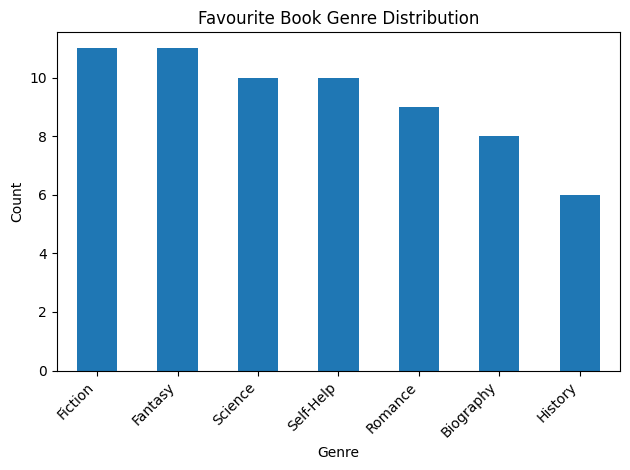

In [25]:
#to create a bar chart of Favorite_Book_Genre, this includes sorting 
#the values accending order

genre_counts = df["Favorite_Book_Genre"].value_counts().sort_values(ascending=False)

genre_counts.plot(kind="bar")
plt.title("Favourite Book Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



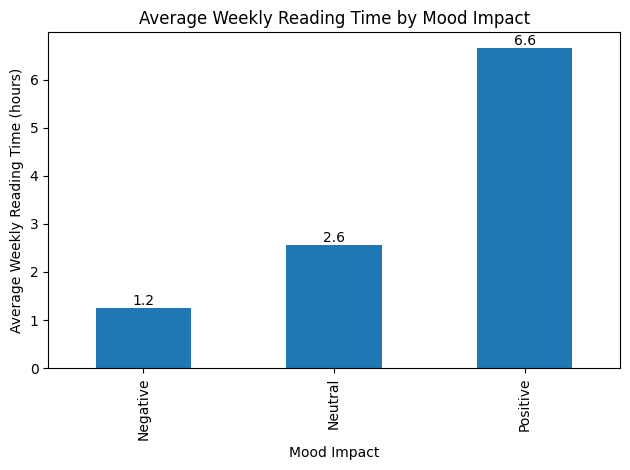

In [26]:
# Calculate mean weekly reading time by mood (ordered)
order = ["Negative", "Neutral", "Positive"]

avg_reading = (df.groupby("Mood_Impact")["Weekly_Reading_Time(hours)"]
                 .mean()
                 .reindex(order))

ax = avg_reading.plot(kind="bar", color="#1f77b4")

ax.set_title("Average Weekly Reading Time by Mood Impact")
ax.set_xlabel("Mood Impact")
ax.set_ylabel("Average Weekly Reading Time (hours)")

# Add value labels on bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")

plt.tight_layout()
plt.show()

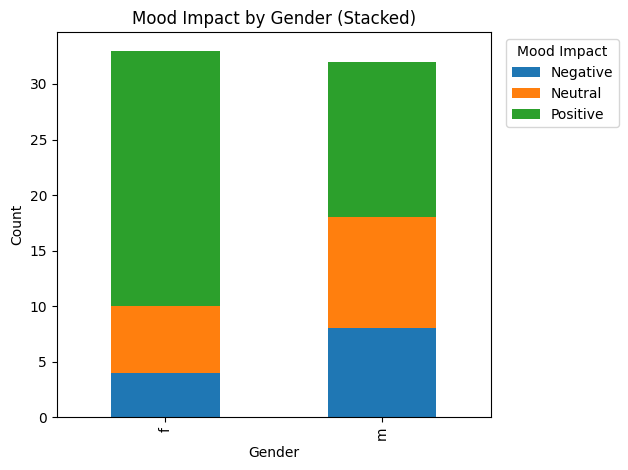

In [27]:
#to create a stacked bar chart of Mood impacts by gender 
ct = pd.crosstab(df["Gender"], df["Mood_Impact"])
ct = ct[["Negative","Neutral","Positive"]]  # order columns if present
ct.plot(kind="bar", stacked=True)

plt.title("Mood Impact by Gender (Stacked)")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Mood Impact", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


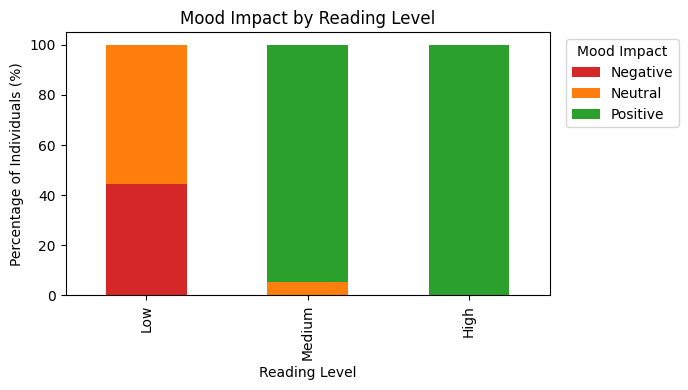

In [28]:
# 1) Create reading level groups (Low / Medium / High)
# Using quantiles keeps group sizes balanced even if the distribution is skewed
df["Reading_Level"] = pd.qcut(
    df["Weekly_Reading_Time(hours)"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# 2) Build a row-normalised crosstab (each row sums to 1)
tab = pd.crosstab(df["Reading_Level"], df["Mood_Impact"], normalize="index")

# 3) Ensure consistent column order
tab = tab.reindex(columns=["Negative", "Neutral", "Positive"])

# 4) Plot as a 100% stacked bar chart
ax = (tab * 100).plot(
    kind="bar",
    stacked=True,
    figsize=(7, 4),
    color=["#d62728", "#ff7f0e", "#2ca02c"]  # red/orange/green
)

ax.set_title("Mood Impact by Reading Level")
ax.set_xlabel("Reading Level")
ax.set_ylabel("Percentage of Individuals (%)")
ax.legend(title="Mood Impact", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [29]:
#Examine descriptive stats, count, measures of central tendency (mean, median)
#measures of spread (standard deviation, quartiles), minimum and maximum

df.describe()

,User_ID,Age,Weekly_Reading_Time(hours)
count,65.00000,65.000000,65.000000
mean,33.00000,33.000000,4.646154
std,18.90767,9.429011,2.718172
min,1.00000,18.000000,1.000000
25%,17.00000,25.000000,2.000000
50%,33.00000,32.000000,5.000000
75%,49.00000,41.000000,7.000000
max,65.00000,50.000000,10.000000


In [30]:
# Calculate count, mean, and median weekly reading time by mood impact

df.groupby("Mood_Impact")["Weekly_Reading_Time(hours)"].agg(["count","mean","median"])

,count,mean,median
Mood_Impact,,,
Negative,12,1.250000,1.0
Neutral,16,2.562500,3.0
Positive,37,6.648649,7.0


In [31]:
#Bin ages into bands, then show mood impact percentages within each age

bins = [17,25,35,45,100]
labels = ["18-25","26-35","36-45","46+"]
df["Age_Band"] = pd.cut(df["Age"], bins=bins, labels=labels)

pd.crosstab(df["Age_Band"], df["Mood_Impact"], normalize="index")

Mood_Impact,Negative,Neutral,Positive
Age_Band,,,
18-25,0.000000,0.055556,0.944444
26-35,0.095238,0.285714,0.619048
36-45,0.388889,0.333333,0.277778
46+,0.375000,0.375000,0.250000


In [32]:
# Show mood impact proportions within each gender

pd.crosstab(df["Gender"], df["Mood_Impact"], normalize="index")

Mood_Impact,Negative,Neutral,Positive
Gender,,,
f,0.121212,0.181818,0.69697
m,0.250000,0.312500,0.43750


In [33]:
# Encode categorical mood impact and gender variables as numeric values

mood_map = {"Negative": -1, "Neutral": 0, "Positive": 1}
gender_map = {"f": 0, "m": 1}

df["Mood_Impact_Num"] = df["Mood_Impact"].map(mood_map)
df["Gender_Num"] = df["Gender"].map(gender_map)

df[["Mood_Impact", "Mood_Impact_Num", "Gender", "Gender_Num"]].head()

,Mood_Impact,Mood_Impact_Num,Gender,Gender_Num
0,Positive,1,f,0
1,Neutral,0,m,1
2,Positive,1,f,0
3,Neutral,0,m,1
4,Positive,1,f,0


In [34]:
# Define outcome and predictor variables and add an intercept for regression

y = df["Mood_Impact_Num"]
X = df[["Weekly_Reading_Time(hours)", "Age", "Gender_Num"]]
X = sm.add_constant(X)  # adds intercept

In [35]:
# Fit an OLS regression model and display the results summary

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Mood_Impact_Num   R-squared:                       0.720
Model:                            OLS   Adj. R-squared:                  0.706
Method:                 Least Squares   F-statistic:                     52.20
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           7.69e-17
Time:                        16:15:28   Log-Likelihood:                -34.617
No. Observations:                  65   AIC:                             77.23
Df Residuals:                      61   BIC:                             85.93
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [36]:
# Build a clean table of regression coefficients and significance statistics
summary_table = pd.DataFrame({
    "Coefficient": model.params,
    "Std Error": model.bse,
    "t-value": model.tvalues,
    "p-value": model.pvalues
})

summary_table


,Coefficient,Std Error,t-value,p-value
const,-0.283954,0.313368,-0.906133,3.684307e-01
Weekly_Reading_Time(hours),0.221161,0.024274,9.110946,5.544242e-13
Age,-0.011051,0.007061,-1.565242,1.226996e-01
Gender_Num,0.011617,0.111960,0.103757,9.177023e-01


In [37]:
# Generate model predictions and calculate residuals

df["Predicted"] = model.predict(X)
df["Residual"] = y - df["Predicted"]
df[["Predicted","Residual"]].head()

,Predicted,Residual
0,0.777778,0.222222
1,-0.183662,0.183662
2,1.286410,-0.286410
3,-0.106170,0.106170
4,1.607166,-0.607166


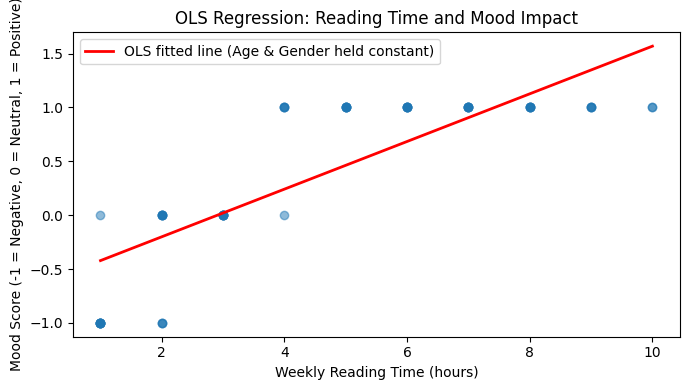

In [38]:
#scatter chart to show the regression results
# Plot the OLS fitted relationship between reading time and mood (age & gender held constant)
x_grid = np.linspace(df["Weekly_Reading_Time(hours)"].min(),
                     df["Weekly_Reading_Time(hours)"].max(), 100)

age_mean = df["Age"].mean()
gender_mean = df["Gender_Num"].mean()

X_grid = pd.DataFrame({
    "Weekly_Reading_Time(hours)": x_grid,
    "Age": age_mean,
    "Gender_Num": gender_mean
})

# Force-add the intercept column
X_grid = sm.add_constant(X_grid, has_constant="add")

y_grid = model.predict(X_grid)

plt.figure(figsize=(7,4))
plt.scatter(df["Weekly_Reading_Time(hours)"], df["Mood_Impact_Num"], alpha=0.5)
plt.plot(x_grid, y_grid, color="red", linewidth=2,
         label="OLS fitted line (Age & Gender held constant)")

plt.xlabel("Weekly Reading Time (hours)")
plt.ylabel("Mood Score (-1 = Negative, 0 = Neutral, 1 = Positive)")
plt.title("OLS Regression: Reading Time and Mood Impact")
plt.legend()
plt.tight_layout()
plt.show()

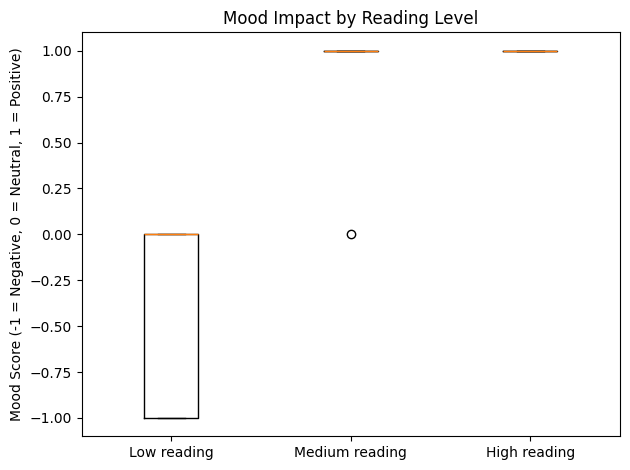

In [39]:
# Compare mood score distributions across reading level groups using a box plot

df["Reading_Group"] = pd.cut(
    df["Weekly_Reading_Time(hours)"],
    bins=[-1, 3, 6, 10],
    labels=["Low", "Medium", "High"]
)

plt.boxplot(
    [df[df["Reading_Group"]=="Low"]["Mood_Impact_Num"],
     df[df["Reading_Group"]=="Medium"]["Mood_Impact_Num"],
     df[df["Reading_Group"]=="High"]["Mood_Impact_Num"]],
    tick_labels=["Low reading", "Medium reading", "High reading"]
)

plt.ylabel("Mood Score (-1 = Negative, 0 = Neutral, 1 = Positive)")
plt.title("Mood Impact by Reading Level")
plt.tight_layout()
plt.show()

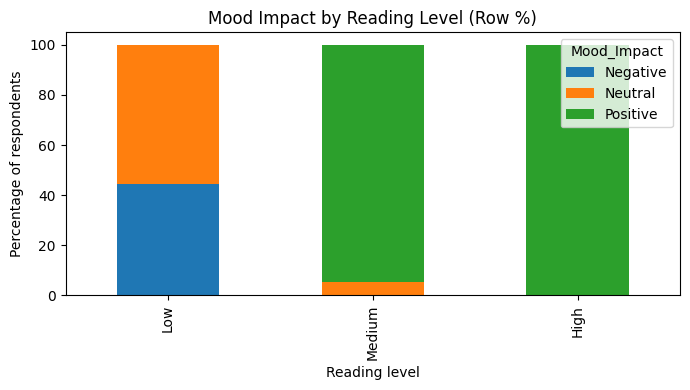

In [40]:
# Show mood impact percentages by reading level using a stacked bar chart

ct = pd.crosstab(df["Reading_Group"], df["Mood_Impact"], normalize="index")
ct = ct[["Negative", "Neutral", "Positive"]]  # order

(ct*100).plot(kind="bar", stacked=True, figsize=(7,4))
plt.title("Mood Impact by Reading Level (Row %)")
plt.ylabel("Percentage of respondents")
plt.xlabel("Reading level")
plt.tight_layout()
plt.show()

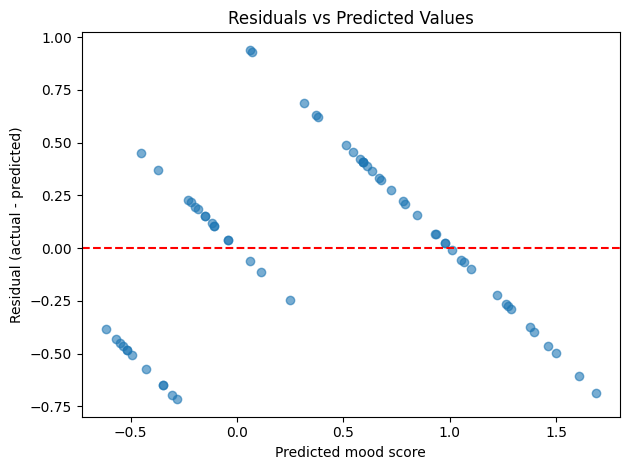

In [41]:
# Plot residuals against predicted values to assess model fit

plt.scatter(df["Predicted"], df["Residual"], alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted mood score")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residuals vs Predicted Values")
plt.tight_layout()
plt.show()